# Load Dataset

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("nova_pay_transactions.csv")

df.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [9]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             10200 non-null  object 
 1   customer_id                10200 non-null  object 
 2   timestamp                  10171 non-null  object 
 3   home_country               10200 non-null  object 
 4   source_currency            10200 non-null  object 
 5   dest_currency              10200 non-null  object 
 6   channel                    10200 non-null  object 
 7   amount_src                 10200 non-null  object 
 8   amount_usd                 9895 non-null   float64
 9   fee                        9905 non-null   float64
 10  exchange_rate_src_to_dest  10200 non-null  float64
 11  device_id                  10200 non-null  object 
 12  new_device                 10200 non-null  bool   
 13  ip_address                 9895 non-null   obj

,amount_usd,fee,exchange_rate_src_to_dest,ip_risk_score,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
count,9895.000000,9905.000000,10200.000000,10200.000000,10200.000000,9905.000000,10200.000000,10200.000000,10200.000000,10200.000000,10200.000000,10200.000000
mean,410.973958,110.915958,151.070118,0.355567,422.387353,0.684846,0.002549,0.241320,0.131471,0.232255,0.042412,0.019314
std,1428.534323,1013.983451,360.401932,0.230242,339.577111,0.254493,0.052334,0.103254,0.950315,0.981683,0.083074,0.137632
min,7.230000,-1.000000,0.592000,0.004000,4.000000,-0.100000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000
25%,88.260000,2.310000,1.000000,0.200000,257.000000,0.522000,0.000000,0.166000,0.000000,0.000000,0.000000,0.000000
50%,151.890000,3.330000,7.142857,0.308000,298.000000,0.779000,0.000000,0.223000,0.000000,0.000000,0.000000,0.000000
75%,267.935000,5.040000,61.666667,0.440000,718.000000,0.923000,0.000000,0.332000,0.000000,0.000000,0.000000,0.000000
max,12498.570000,9999.990000,1388.888889,1.200000,1092.000000,0.971000,2.000000,0.554000,8.000000,9.000000,0.250000,1.000000


# Data Preparation
Handle Missing Values

In [10]:
df.isnull().sum()

,0
transaction_id,0
customer_id,0
timestamp,29
home_country,0
source_currency,0
dest_currency,0
channel,0
amount_src,0
amount_usd,305
fee,295


fill numeric values

In [11]:
df.fillna(df.median(numeric_only=True), inplace=True)

Fill categorical values

In [12]:
df.fillna("Unknown", inplace=True)

**Convert Timestamp**

In [14]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce', format='mixed')

**Extract Time Features**

In [15]:
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day
df['month'] = df['timestamp'].dt.month
df['day_of_week'] = df['timestamp'].dt.dayofweek

# Exploratory Data Analysis (EDA)

**Fraud Distribution**

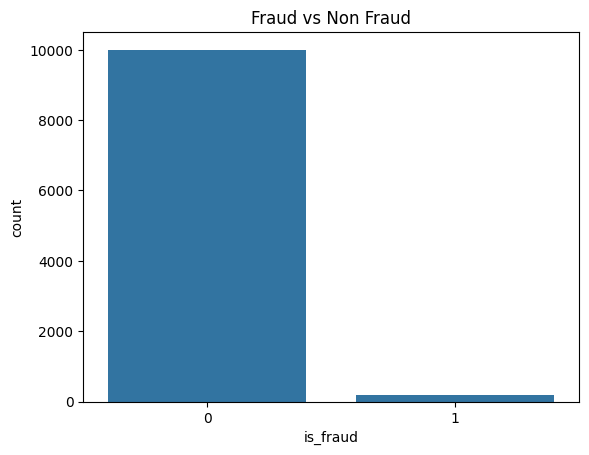

In [16]:
sns.countplot(x='is_fraud', data=df)
plt.title("Fraud vs Non Fraud")
plt.show()

**Transaction Amount Distribution**

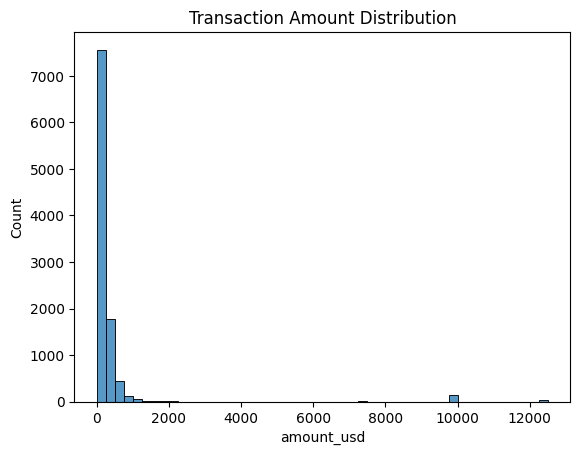

In [19]:
sns.histplot(df['amount_usd'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

**Fraud vs Amount**

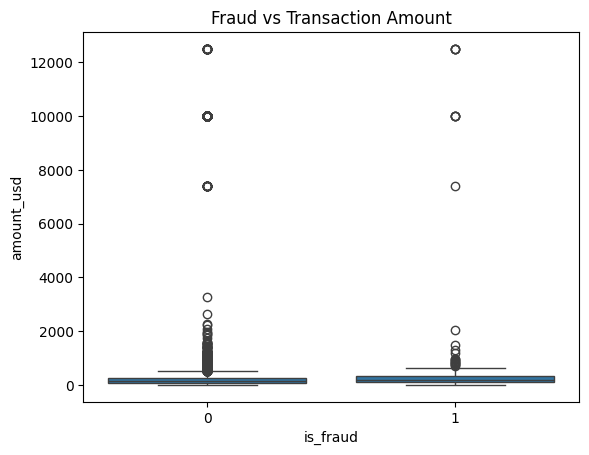

In [21]:
sns.boxplot(x='is_fraud', y='amount_usd', data=df)
plt.title("Fraud vs Transaction Amount")
plt.show()

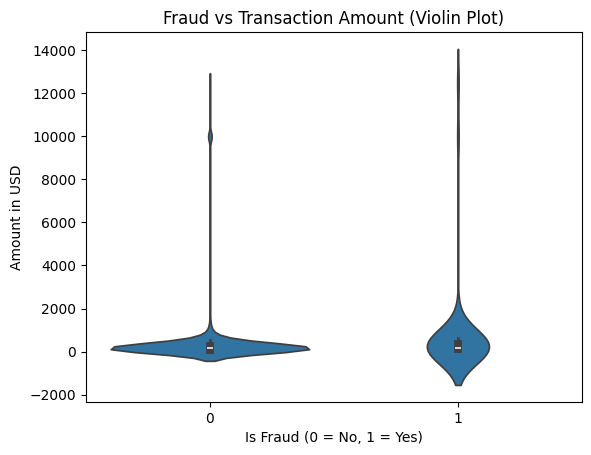

In [22]:
sns.violinplot(x='is_fraud', y='amount_usd', data=df)
plt.title("Fraud vs Transaction Amount (Violin Plot)")
plt.xlabel("Is Fraud (0 = No, 1 = Yes)")
plt.ylabel("Amount in USD")
plt.show()

# Feature Engineering

**Customer transaction frequency**

In [23]:
df['customer_txn_count'] = df.groupby('customer_id')['transaction_id'].transform('count')

**Average customer spend**

In [25]:
df['avg_customer_amount'] = df.groupby('customer_id')['amount_usd'].transform('mean')

**Merchant risk score**

In [28]:
merchant_fraud_rate = df.groupby('channel')['is_fraud'].mean()

df['merchant_risk'] = df['channel'].map(merchant_fraud_rate)

# Prepare Data for Machine Learning

**Drop unnecessary columns:**

In [30]:
df = df.drop(['transaction_id','timestamp'], axis=1)

**Convert categorical variables**

In [31]:
df = pd.get_dummies(df, drop_first=True)

**Define X and y**

In [45]:
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

# Fill any remaining NaNs in X before SMOTE, likely from time-derived features
X.fillna(X.median(), inplace=True)

# Train/Test Split

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Machine Learning Model

In [34]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced'
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200)

# Check Training Score

In [36]:
model.score(X_train, y_train) * 100

86.99754901960785

# Model Evaluation

In [37]:
from sklearn.metrics import classification_report, confusion_matrix

preds = model.predict(X_test)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.99      0.86      0.92      2001
           1       0.04      0.33      0.08        39

    accuracy                           0.85      2040
   macro avg       0.51      0.60      0.50      2040
weighted avg       0.97      0.85      0.90      2040



**Confusion matrix**

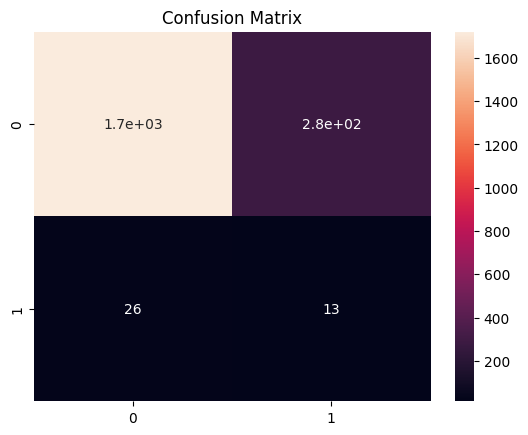

In [38]:
sns.heatmap(confusion_matrix(y_test,preds), annot=True)
plt.title("Confusion Matrix")
plt.show()

# Feature Importance

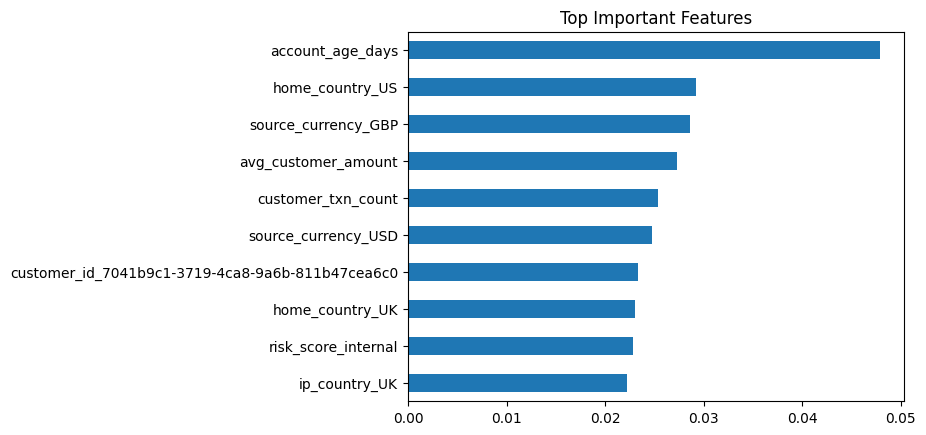

In [39]:
importances = pd.Series(model.feature_importances_, index=X.columns)

importances.sort_values().tail(10).plot(kind='barh')
plt.title("Top Important Features")
plt.show()

# Save the model

In [40]:
import joblib

joblib.dump(model, "fraud_model.pkl")
joblib.dump(X.columns, "model_features.pkl")

['model_features.pkl']

## Addressing Class Imbalance with SMOTE

In [52]:
from imblearn.over_sampling import SMOTE

# Ensure X_train is completely free of NaNs before SMOTE
X_train.fillna(X_train.median(), inplace=True)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Shape of X_train before SMOTE:", X_train.shape)
print("Shape of X_train after SMOTE:", X_train_resampled.shape)
print("Distribution of y_train before SMOTE:\n", y_train.value_counts())
print("Distribution of y_train after SMOTE:\n", y_train_resampled.value_counts())

Shape of X_train before SMOTE: (8160, 19596)
Shape of X_train after SMOTE: (16004, 19596)
Distribution of y_train before SMOTE:
 is_fraud
0    8002
1     158
Name: count, dtype: int64
Distribution of y_train after SMOTE:
 is_fraud
0    8002
1    8002
Name: count, dtype: int64


## Retrain Model with Resampled Data

In [53]:
from sklearn.ensemble import RandomForestClassifier

model_resampled = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced', # Still good to keep this, even with SMOTE
    random_state=42
)

model_resampled.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

## Evaluate Model with Resampled Data

              precision    recall  f1-score   support

           0       0.99      0.86      0.92      2001
           1       0.05      0.33      0.08        39

    accuracy                           0.85      2040
   macro avg       0.52      0.60      0.50      2040
weighted avg       0.97      0.85      0.90      2040



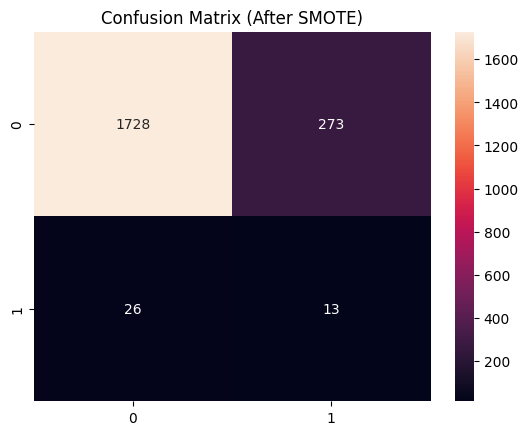

In [54]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

preds_resampled = model_resampled.predict(X_test)

print(classification_report(y_test, preds_resampled))

sns.heatmap(confusion_matrix(y_test,preds_resampled), annot=True, fmt='d')
plt.title("Confusion Matrix (After SMOTE)")
plt.show()

# Save the Resampled Model

In [55]:
import joblib

joblib.dump(model_resampled, "fraud_model_resampled.pkl")
joblib.dump(X.columns, "model_resampled_features.pkl")
print("Model trained with resampled data saved as 'fraud_model_resampled.pkl'")
print("Model features saved as 'model_resampled_features.pkl'")

Model trained with resampled data saved as 'fraud_model_resampled.pkl'
Model features saved as 'model_resampled_features.pkl'


# Compare Model Accuracy

In [56]:
from sklearn.metrics import accuracy_score

# Accuracy before SMOTE
preds_before_smote = model.predict(X_test)
accuracy_before_smote = accuracy_score(y_test, preds_before_smote)

# Accuracy after SMOTE
preds_after_smote = model_resampled.predict(X_test)
accuracy_after_smote = accuracy_score(y_test, preds_after_smote)

print(f"Accuracy before SMOTE: {accuracy_before_smote:.4f}")
print(f"Accuracy after SMOTE: {accuracy_after_smote:.4f}")

Accuracy before SMOTE: 0.8500
Accuracy after SMOTE: 0.8534


# Exploratory Data Analysis (EDA) Report

This report summarizes the key insights derived from the exploratory data analysis of the transaction dataset.

## 1. Fraud Distribution

The count plot of 'is_fraud' reveals a significant class imbalance in the dataset. The vast majority of transactions are not fraudulent (represented by 0), while fraudulent transactions (represented by 1) are a small minority. This imbalance is crucial to consider during model training and evaluation.

## 2. Transaction Amount Distribution

The histogram of `amount_usd` shows the distribution of transaction amounts. Most transactions fall within a lower value range, with a long tail indicating a few high-value transactions. This distribution suggests that while many transactions are small, there are occasional large transactions that could be significant in fraud detection.

## 3. Fraud vs Transaction Amount

### Box Plot (Fraud vs Transaction Amount)

The box plot comparing `is_fraud` and `amount_usd` indicates that fraudulent transactions generally have a different distribution of amounts compared to non-fraudulent ones. While there is overlap, the median and spread of fraudulent transaction amounts might differ, suggesting `amount_usd` is a relevant feature.

### Violin Plot (Fraud vs Transaction Amount)

The violin plot provides a more detailed view of the distribution of `amount_usd` for both fraudulent and non-fraudulent transactions. It clearly shows the density of transactions across different amount ranges for each category, offering a richer understanding than a box plot. For instance, it might highlight specific amount ranges where fraudulent activity is more concentrated or where the distribution differs significantly.